In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
# Descargar set de datos
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

# Obtener datos de entrenamiento y pruebas
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

# Nombres de las categorías
nombres_clases = metadatos.features['label'].names
print("Clases disponibles:", nombres_clases)

Clases disponibles: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255.0 # Corregido de imagenes l=255
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

# Uso de caché para optimizar lectura
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

# Variables de lote y conteo
TAMANO_LOTE = 32
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples

# Mezclar y agrupar en lotes
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [4]:
# Crear el modelo secuencial
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

# Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Entrenar el modelo
pasos_por_epoca = math.ceil(num_ej_entrenamiento / TAMANO_LOTE)
historial = modelo.fit(datos_entrenamiento, epochs=5, steps_per_epoch=pasos_por_epoca)

Epoch 1/5


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1773100944.670040  184027 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 413us/step - accuracy: 0.8199 - loss: 0.5089
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 411us/step - accuracy: 0.8594 - loss: 0.3876
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 447us/step - accuracy: 0.8726 - loss: 0.3502
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step - accuracy: 0.8806 - loss: 0.3294
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 413us/step - accuracy: 0.8841 - loss: 0.3130


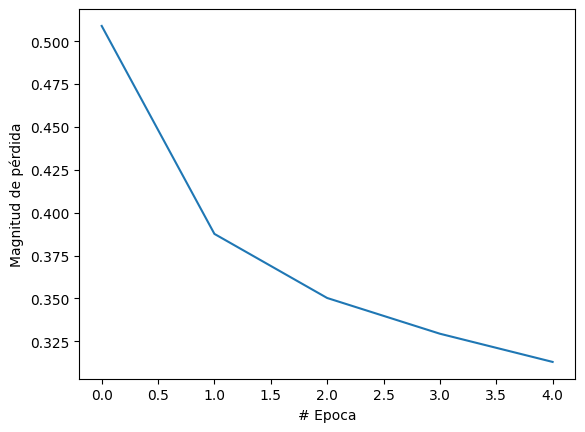

In [5]:
# Ver la funcion de perdida
plt.figure()
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


W0000 00:00:1773100949.319727  184207 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773100949.319809  184207 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


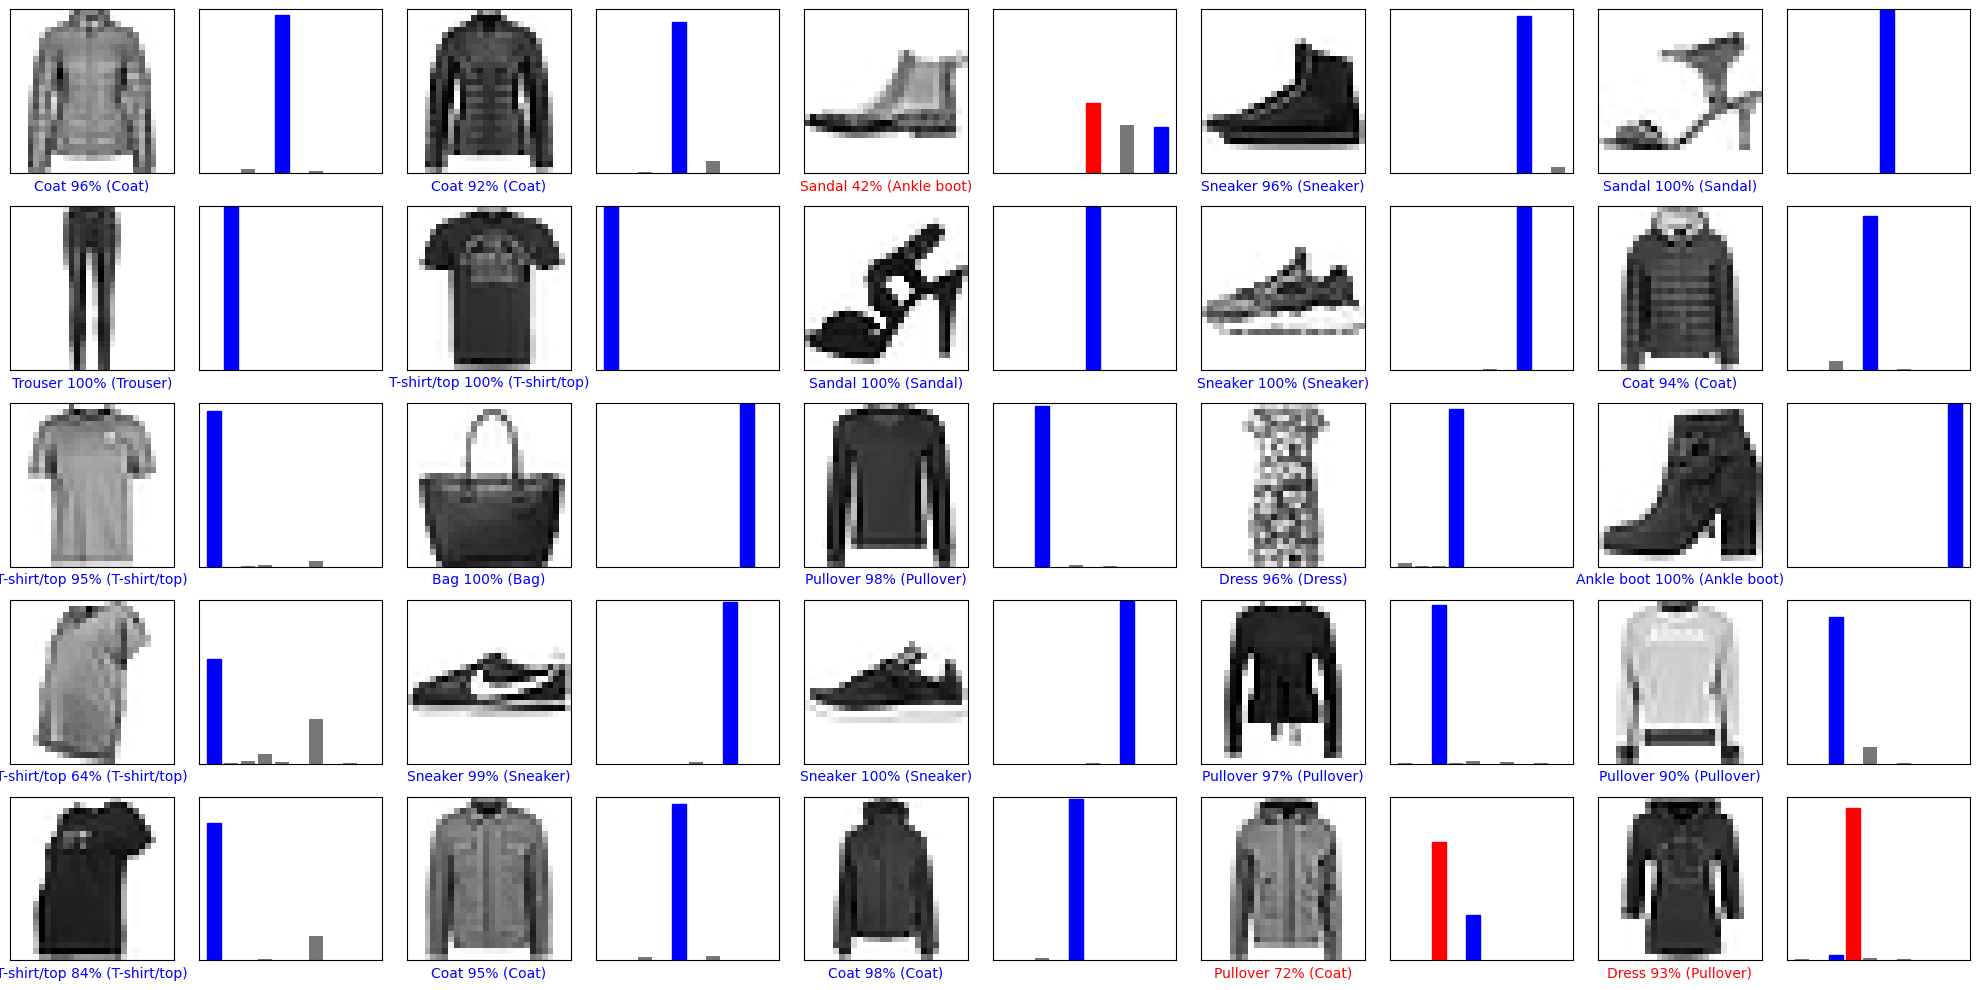

In [6]:
# Tomar el primer lote de pruebas
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()
    predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    color = 'blue' if etiqueta_prediccion == etiqueta_real else 'red'

    # Corrección del error de formato en el PDF
    plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                100*np.max(arr_predicciones),
                                nombres_clases[etiqueta_real]),
                                color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

# Graficar 25 imágenes
filas, columnas = 5, 5
num_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)
plt.tight_layout()
plt.show()

In [7]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

# 1. Exportar el modelo en formato .h5
modelo.save('modelo_clasificacion_ropa.h5')
print("Modelo guardado exitosamente como 'modelo_clasificacion_ropa.h5'\n")

# 2. Instanciar componentes gráficos del widget
uploader = widgets.FileUpload(accept='image/*', multiple=False)
out = widgets.Output() # Contenedor obligatorio para renderizado en VS Code

display(uploader, out)

def procesar_y_predecir(change):
    # Limpiar predicción anterior en la interfaz
    out.clear_output()
    
    with out:
        # Extraer el archivo según versión de ipywidgets (soporte v7 y v8)
        if isinstance(uploader.value, tuple) or isinstance(uploader.value, list):
            content = uploader.value[0]['content'] 
        else:
            nombre_archivo = list(uploader.value.keys())[0]
            content = uploader.value[nombre_archivo]['content'] 
        
        # Procesamiento a escala de grises
        imagen_pil = Image.open(io.BytesIO(content)).convert('L')
        imagen_np = np.array(imagen_pil)
        
        # Invertir la matriz: el dataset entrena con fondo negro (0) y trazado blanco (255)
        imagen_np = cv2.bitwise_not(imagen_np)
        
        # Redimensionar al formato de entrada de la red neuronal (28x28)
        imagen_redimensionada = cv2.resize(imagen_np, (28, 28))
        
        # Normalizar vector de (0-255) a (0-1)
        imagen_final = imagen_redimensionada / 255.0
        
        # Expandir tensor de (28, 28) a (1, 28, 28, 1) para Keras
        imagen_prediccion = np.expand_dims(imagen_final, axis=0)
        imagen_prediccion = np.expand_dims(imagen_prediccion, axis=-1)
        
        # Ejecutar predicción
        prediccion = modelo.predict(imagen_prediccion)
        clase_predicha = nombres_clases[np.argmax(prediccion[0])]
        confianza = np.max(prediccion[0]) * 100
        
        # Renderizado en salida estándar
        print(f"Predicción: {clase_predicha}")
        print(f"Confianza: {confianza:.2f}%")
        
        plt.figure()
        plt.imshow(imagen_redimensionada, cmap=plt.cm.binary)
        plt.title(f"{clase_predicha} ({confianza:.2f}%)")
        plt.axis('off')
        plt.show()

# Disparador asíncrono
uploader.observe(procesar_y_predecir, names='value')

Modelo guardado exitosamente como 'modelo_clasificacion_ropa.h5'



FileUpload(value=(), accept='image/*', description='Upload')

Output()

# Actividad: Clasificación de Ropa con Fashion MNIST

## 1. ¿Qué significa el parámetro `as_supervised`?

El parámetro `as_supervised=True` indica que el dataset se cargará en formato supervisado. Esto significa que cada elemento del dataset se devolverá como un par:

(imagen, etiqueta)

- imagen: matriz de pixeles que representa la prenda.
- etiqueta: número entero que representa la categoría de la prenda.

Este formato permite entrenar modelos de aprendizaje supervisado, ya que el modelo recibe los datos de entrada junto con la respuesta correcta.

---

## 2. ¿Qué significa el parámetro `with_info`?

El parámetro `with_info=True` permite obtener información adicional sobre el dataset al momento de descargarlo.

Esta información incluye:

- número total de ejemplos
- número de ejemplos de entrenamiento
- número de ejemplos de prueba
- nombres de las categorías
- descripción del dataset
- estructura de los datos

La información se guarda en una variable llamada metadatos.

---

## 3. ¿Para qué se utiliza la función `map()`?

La función `map()` se utiliza para aplicar una función a todos los elementos de un dataset.

En este ejercicio se usa para aplicar la función de normalización a cada imagen del dataset.

Ejemplo:

    datos_entrenamiento = datos_entrenamiento.map(normalizar)
    datos_pruebas = datos_pruebas.map(normalizar)

Esto permite modificar cada imagen del dataset automáticamente.

---

## 4. ¿Qué es la normalización de datos?

La normalización es el proceso de escalar los valores de los datos a un rango más pequeño.

En este ejercicio los pixeles tienen valores entre 0 y 255. Para mejorar el entrenamiento de la red neuronal, los valores se dividen entre 255 para convertirlos al rango de 0 a 1.

Esto ayuda a que el modelo:

- entrene más rápido
- tenga mayor estabilidad
- obtenga mejores resultados

---

## 5. ¿Por qué se utiliza `shuffle()`?

La función `shuffle()` se utiliza para mezclar los datos de entrenamiento de forma aleatoria.

Esto evita que el modelo aprenda patrones basados en el orden en el que aparecen los datos y mejora la capacidad de generalización del modelo.

---

## 6. ¿Por qué se utiliza `batch()`?

La función `batch()` divide el dataset en pequeños grupos llamados lotes.

En lugar de procesar todos los datos al mismo tiempo, el modelo procesa pequeños grupos de imágenes.

Esto permite:

- reducir el uso de memoria
- acelerar el entrenamiento
- mejorar la eficiencia del aprendizaje

En este ejercicio se utiliza un tamaño de lote de 32.

---

## 7. ¿Por qué se utiliza `repeat()`?

La función `repeat()` permite que el dataset se repita varias veces durante el entrenamiento.

Esto permite que el modelo pueda recorrer los datos múltiples veces durante las diferentes épocas de entrenamiento.

---

## 8. ¿Qué hace la capa `Flatten()`?

La capa `Flatten()` convierte una matriz en un vector de una sola dimensión.

En este ejercicio las imágenes tienen un tamaño de 28 x 28 pixeles.

La capa Flatten transforma la matriz de 28 x 28 en un vector de 784 valores, permitiendo que las capas densas de la red neuronal puedan procesar los datos.

---

## 9. ¿Qué es la función de activación ReLU?

La función de activación ReLU (Rectified Linear Unit) introduce no linealidad en la red neuronal.

Su fórmula es:

f(x) = max(0, x)

Esto significa que:

- si el valor es negativo devuelve 0
- si el valor es positivo devuelve el mismo valor

ReLU es una de las funciones más utilizadas porque acelera el entrenamiento y permite aprender patrones complejos.

---

## 10. ¿Qué es la función Softmax?

La función Softmax se utiliza en la capa de salida de redes neuronales para problemas de clasificación multiclase.

Esta función convierte los valores de salida del modelo en probabilidades cuya suma es igual a 1.

La clase con la probabilidad más alta es la predicción final del modelo.

---

## 11. ¿Qué es el formato `.h5`?

El formato `.h5` corresponde al formato HDF5 (Hierarchical Data Format version 5).

Es un formato utilizado para guardar modelos de aprendizaje automático entrenados.

Este formato permite almacenar:

- la arquitectura del modelo
- los pesos entrenados
- la configuración del entrenamiento
- los parámetros del optimizador

---

## 12. ¿Para qué sirve el formato `.h5`?

El formato `.h5` permite guardar un modelo entrenado para poder reutilizarlo posteriormente.

Sus principales usos son:

- guardar el modelo entrenado
- cargar el modelo en otro programa
- compartir el modelo con otros usuarios
- evitar volver a entrenar el modelo

Ejemplo para guardar el modelo:

    modelo.save("modelo_ropa.h5")

Ejemplo para cargar el modelo posteriormente:

    modelo = tf.keras.models.load_model("modelo_ropa.h5")